# MiniBatch K-Means - H&M (extended)


Evaluación del número de clusters y ajuste final del modelo. El `k` recomendado se selecciona mediante el mayor coeficiente silhouette.


In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

from modeling_functions import (
    minibatch_kmeans_metrics,
    plot_clustering_metrics,
    analyze_clusters,
    fit_clustering_model,
    save_clustering_metrics,
)
import pandas as pd

## Carga y preparación de los datos


In [2]:
df_scaled = pd.read_csv("../../../scaled_data/hym_scaled.csv")
df_original = pd.read_csv("../../../extended_datasets/hym_model_extended.csv")

# Conserva en el escalado solo las variables incluidas en esta versión del dataset.
columnas_modelo = [col for col in df_original.columns if col in df_scaled.columns]
df_scaled_modelo = df_scaled[columnas_modelo].copy()
X = df_scaled_modelo.drop(columns=["customer_id"], errors="ignore")

print(f"Observaciones: {X.shape[0]:,}")
print(f"Variables de clustering: {X.shape[1]}")
display(X.head())

Observaciones: 1,362,281
Variables de clustering: 16


,recency,frequency,monetary,avg_basket_size,std_basket_size,avg_price,std_price,avg_days_between_purchases,std_days_between_purchases,unique_articles,unique_product_types,unique_product_groups,unique_sections,unique_garment_groups,article_variety_ratio,channel_2_ratio
0,-1.216313,0.926194,0.765377,-0.523798,0.210045,0.432196,0.617279,0.720704,0.918735,0.564508,0.998377,0.182468,0.679223,0.914649,-0.000656,-0.225281
1,-0.614156,1.811026,1.771317,0.374886,1.273567,0.375024,0.745891,0.329096,0.667697,1.585622,1.666834,1.502382,1.692838,1.596049,-1.120686,0.689212
2,-1.404203,0.565013,0.847795,-0.224068,0.869573,1.056084,0.735802,0.989724,1.301171,0.315278,0.699291,0.182468,0.822147,0.761901,-0.886381,0.832742
3,1.106440,-1.007279,-1.056769,-0.593223,-1.065388,0.396012,-1.679728,-1.316863,-1.029689,-1.079040,-1.414917,-1.137446,-1.361096,-1.418672,0.663637,0.832742
4,-0.918963,0.413566,0.433500,-0.478748,0.128600,0.848051,0.269839,1.038340,1.171898,0.191304,0.581088,0.622439,0.519447,0.397551,0.127092,0.452939


## Evaluación del número de clusters


In [3]:
resultados_minibatch = minibatch_kmeans_metrics(X)
display(resultados_minibatch)

,k,silhouette,calinski_harabasz,davies_bouldin,inertia,tiempo_segundos
0,2,0.367222,1.032176e+06,1.103176,1.240101e+07,6.223927
1,3,0.252821,7.382257e+05,1.448840,1.046021e+07,1.672174
2,4,0.211193,5.837979e+05,1.745862,9.537756e+06,3.482930
3,5,0.196259,4.927570e+05,1.829775,8.928382e+06,4.981619
4,6,0.190677,4.262742e+05,1.782626,8.501694e+06,3.101283
5,7,0.187456,3.942369e+05,1.693060,7.973530e+06,3.422553
6,8,0.194021,3.749166e+05,1.611859,7.453140e+06,5.386915
7,9,0.175012,3.448792e+05,1.678554,7.207430e+06,5.013314
8,10,0.176016,3.301434e+05,1.663111,6.855583e+06,5.388394


In [4]:
tabla_metricas = save_clustering_metrics(
    resultados_minibatch,
    model_name="minibatch",
    dataset_name="hym",
    dataset_version="extended",
)

print("Métricas consolidadas en ../../../results/clustering_metrics.csv")
display(tabla_metricas)

Métricas consolidadas en ../../../results/clustering_metrics.csv


,model,dataset,dataset_version,k,silhouette,calinski_harabasz,davies_bouldin,inertia,tiempo_segundos,n_clusters_found,fpc,objective_function,iterations,bic,aic
0,birch,hym,extended,2,0.340654,930935.773165,1.105585,NaN,56.925452,2.0,NaN,NaN,NaN,NaN,NaN
1,birch,hym,extended,3,0.230760,688890.908136,1.436553,NaN,55.993544,3.0,NaN,NaN,NaN,NaN,NaN
2,birch,hym,extended,4,0.203823,524871.689920,1.792945,NaN,55.849959,4.0,NaN,NaN,NaN,NaN,NaN
3,birch,hym,extended,5,0.191449,438249.783633,1.834154,NaN,56.909790,5.0,NaN,NaN,NaN,NaN,NaN
4,birch,hym,extended,6,0.148712,376866.681427,2.094143,NaN,56.928501,6.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247,minibatch,instacart,simple,6,0.287861,92542.785246,1.110500,191238.961903,0.476716,NaN,NaN,NaN,NaN,NaN,NaN
248,minibatch,instacart,simple,7,0.287363,88688.845444,1.083745,173472.413504,0.090507,NaN,NaN,NaN,NaN,NaN,NaN
249,minibatch,instacart,simple,8,0.284887,90539.561492,1.089686,152061.334109,0.358054,NaN,NaN,NaN,NaN,NaN,NaN
250,minibatch,instacart,simple,9,0.282639,87440.639855,1.070433,140993.880428,0.330287,NaN,NaN,NaN,NaN,NaN,NaN


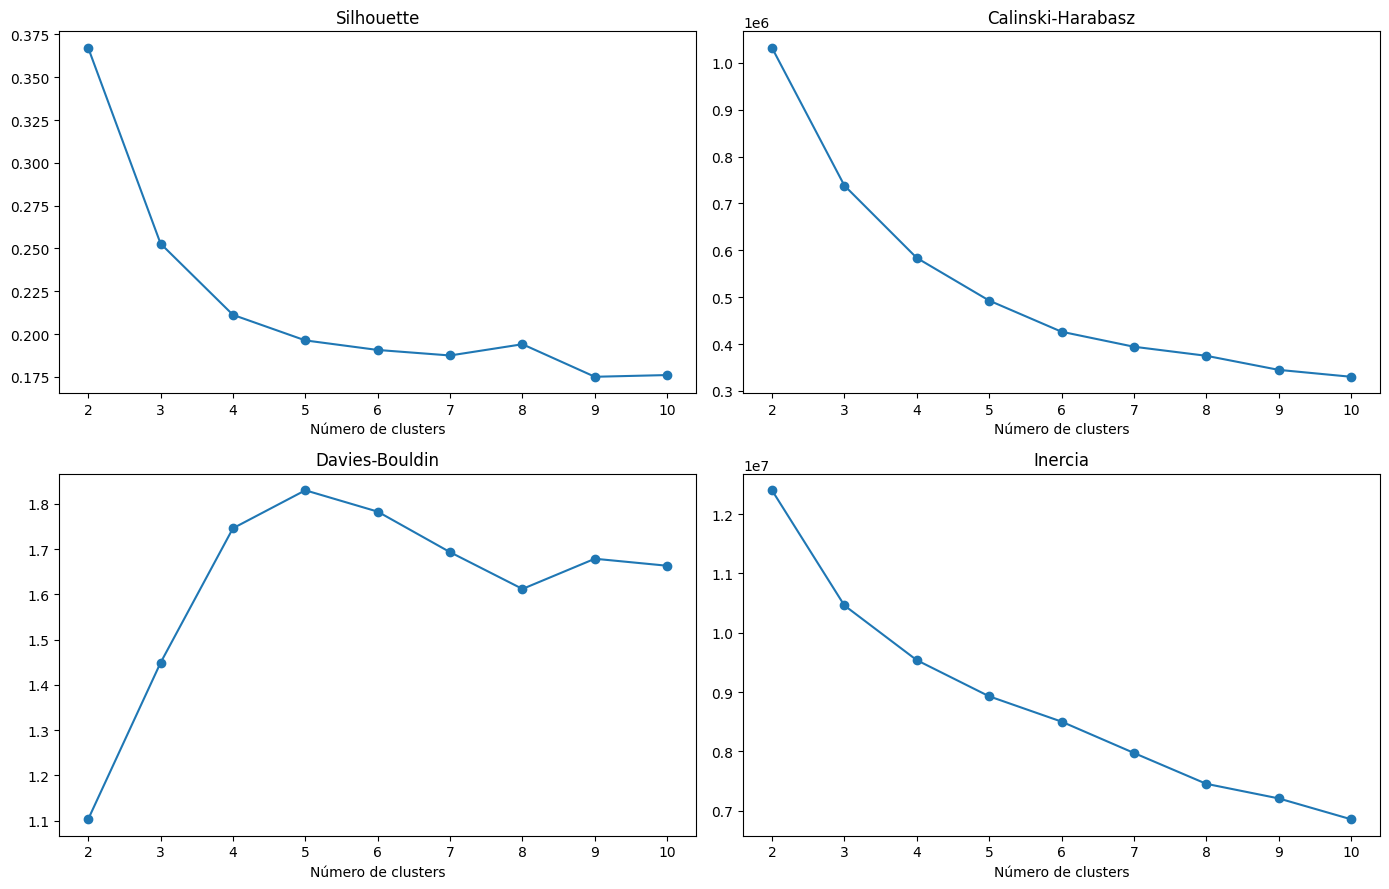

In [5]:
plot_clustering_metrics(
    resultados_minibatch,
    fourth_metric="inertia",
    fourth_title="Inercia",
)

## Ajuste final y perfil de los clusters


In [6]:
modelo, labels = fit_clustering_model(
    model_name="minibatch",
    k=2,
    X=X,
)

cluster_sizes, porcentajes, perfil_clusters, df_clusterizado = analyze_clusters(
    labels=labels,
    df_scaled=df_scaled_modelo,
    df_original=df_original,
    id_col="customer_id",
)

print("Tamaño de los clusters:")
display(cluster_sizes)
print("Porcentaje de clientes:")
display(porcentajes)
print("Perfil medio de los clusters:")
display(perfil_clusters)

Tamaño de los clusters:


cluster
0    654269
1    708012
Name: count, dtype: int64

Porcentaje de clientes:


cluster
0    48.03
1    51.97
Name: proportion, dtype: float64

Perfil medio de los clusters:


,recency,frequency,monetary,avg_basket_size,std_basket_size,avg_price,std_price,avg_days_between_purchases,std_days_between_purchases,unique_articles,unique_product_types,unique_product_groups,unique_sections,unique_garment_groups,article_variety_ratio,channel_2_ratio
cluster,,,,,,,,,,,,,,,,
0,361.512,1.448,0.111,3.064,0.334,0.030,0.008,39.180,6.527,3.578,2.414,1.795,2.127,2.151,0.923,0.700
1,120.301,11.486,1.147,3.912,2.602,0.028,0.015,80.453,68.085,35.261,12.435,5.240,9.856,8.949,0.888,0.628


- Cluster 0 - Clientes activos, diversos y de alto valor (52,65%): presentan menor recencia, alta frecuencia y gasto, además de cestas mayores. Compran una variedad amplia de artículos y recorren muchas más categorías y secciones.
- Cluster 1 - Clientes inactivos y de bajo valor (47,35%): llevan mucho tiempo sin comprar, apenas realizan una compra y generan poco gasto. Su diversidad absoluta es reducida y su vinculación con la marca es baja.